# Profilado y EDA con Python
---

## Enunciado

Seleccionar un conjunto de datos que presenta problemas de calidad, incluyendo valores faltantes, duplicados, inconsistencias en variables categóricas y posibles valores atípicos. El objetivo de esta actividad es aplicar técnicas de **profilado de datos y análisis exploratorio (EDA)** utilizando Python, con el fin de comprender la estructura del dataset, detectar problemas de calidad y obtener conclusiones iniciales.

### 1. Analizar el dataset inicial

In [135]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [136]:
df = pd.read_csv('cambio_genero.csv')
df.head()

,provincia_id,provincia_nombre,genero,edad_actual_grandes_grupos,cantidad
0,6,Buenos Aires,F,0 a 17,91
1,6,Buenos Aires,F,18 a 29,928
2,6,Buenos Aires,F,30 a 39,816
3,6,Buenos Aires,F,40 y mas,1240
4,6,Buenos Aires,M,0 a 17,380


Frecuencia de personas vivas identificadas que realizaron el trámite de rectificación de género en el DNI, conforme a la Ley 26.743 y el Decreto 476/21, desglosadas por provincia de residencia, género y edad actual, en el período comprendido entre 2011 y mayo 2024

| Campos                        |                                                                                                       |
| --                            |--                                                                                                     |
| **provincia_id**              | Código designado por el INDEC para cada Provincia. Incluye CABA                                       |
| **provincia_nombre**          | Provincia de residencia en el DNI de las personas que realizaron el cambio de género en el DNI        |
| **genero**                    | Categoría de género elegida por las personas que rectificaron el sexo asignado al nacer en el DNI     |
| **edad_actual_grande_grupos** | Grupos etarios de la edad actual de las personas que rectificaron el sexo asignado al nacer en el DNI |
| **cantidad**                  | Cantidad de personas que rectificaron el sexo asignado al nacer en el DNI                             |

#### Identificar valores nulos

In [137]:
df.isnull().sum()

provincia_id                  0
provincia_nombre              0
genero                        1
edad_actual_grandes_grupos    0
cantidad                      0
dtype: int64

#### Detectar registros duplicados

In [138]:
df.duplicated().sum()

3

### 2. Realizar el perfilado de datos

#### Analizar estadísticas descriptivas

In [139]:
df.describe()

,provincia_id,cantidad
count,287.000000,287.000000
mean,53.616725,67.801394
std,28.636853,174.461606
min,6.000000,1.000000
25%,30.000000,5.000000
50%,54.000000,17.000000
75%,78.000000,53.000000
max,99.000000,1955.000000


#### Identificar inconsistencias

In [140]:
df['provincia_nombre'].unique()

array(['Buenos Aires', 'Catamarca', 'Chaco', 'Chubut',
       'Ciudad Autónoma de Buenos Aires', 'Córdoba', 'Corrientes',
       'Entre Ríos', 'Formosa', 'Jujuy', 'La Pampa', 'La Rioja',
       'Mendoza', 'Misiones', 'Neuquén', 'Otro Pais', 'Río Negro',
       'Salta', 'San Juan', 'San Luis', 'Santa Cruz', 'Santa Fe',
       'Santiago del Estero', 'Tierra del Fuego', 'Tucumán'], dtype=object)

In [141]:
df['genero'].unique()

array(['F', 'M', 'X', nan], dtype=object)

In [142]:
df['edad_actual_grandes_grupos'].unique()

array(['0 a 17', '18 a 29', '30 a 39', '40 y mas', '40 y +'], dtype=object)

### 3. Aplicar limpieza de datos

#### Eliminar duplicados

In [143]:
df = df.drop_duplicates()
df.duplicated().sum()

0

#### Imputar valores faltantes

In [144]:
df['genero'] = df['genero'].fillna('Desconocido')
df.isnull().sum()

provincia_id                  0
provincia_nombre              0
genero                        0
edad_actual_grandes_grupos    0
cantidad                      0
dtype: int64

#### Normalizar variables categóricas

In [145]:
df['edad_actual_grandes_grupos'] = df['edad_actual_grandes_grupos'].replace({'40 y +':'40 y mas'})
df['edad_actual_grandes_grupos'].unique()

array(['0 a 17', '18 a 29', '30 a 39', '40 y mas'], dtype=object)

### 4. Realizar análisis exploratorio (EDA)

#### Analizar distribuciones

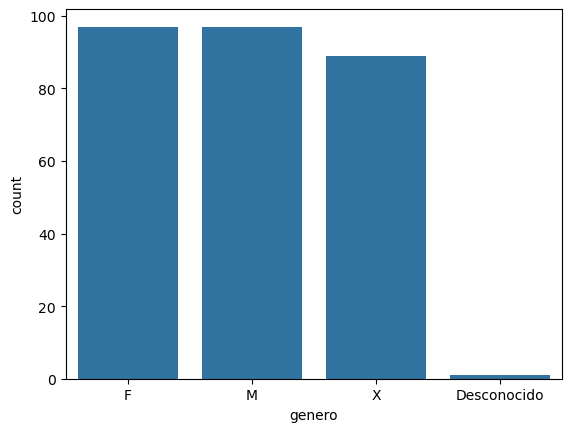

In [146]:
# Distribución por género
sns.countplot(data=df, x='genero')
plt.show()

**Se observa** distribución desigual entre géneros (M suele ser mayor)

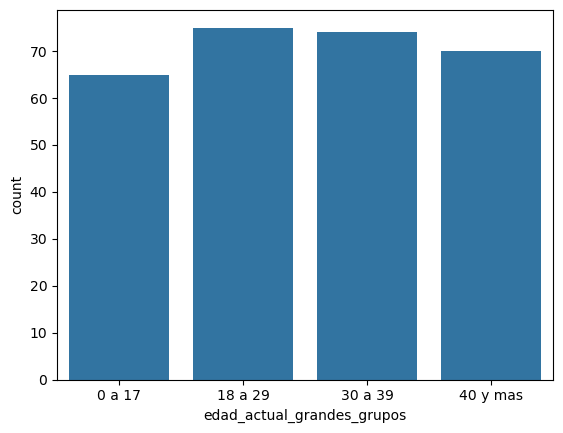

In [147]:
# Distribución por grupo de edad
sns.countplot(data=df, x='edad_actual_grandes_grupos')
plt.show()

#### Detectar outliers

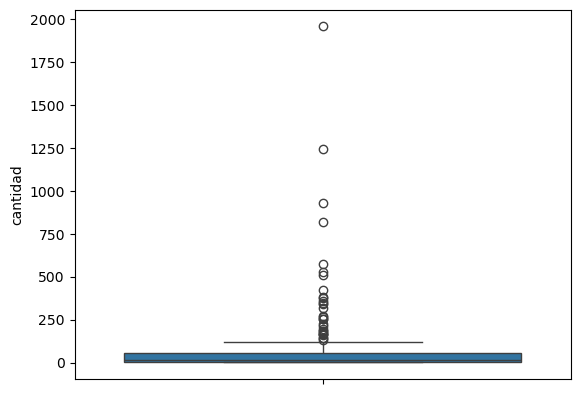

In [148]:
sns.boxplot(data=df, y='cantidad')
plt.show()

**Se observa** en la detección de outliers que Buenos Aires tiene cantidades muy superiores al resto

#### Evaluar relaciones entre variables

In [149]:
# Relación provincia vs cantidad
prov_totales = df.groupby('provincia_nombre')['cantidad'].sum().sort_values(ascending=False)
prov_totales.head()

provincia_nombre
Buenos Aires                       6949
Ciudad Autónoma de Buenos Aires    2338
Santa Fe                           1503
Córdoba                            1489
Salta                               695
Name: cantidad, dtype: int64

**Se observa** provincias chicas con valores muy bajos

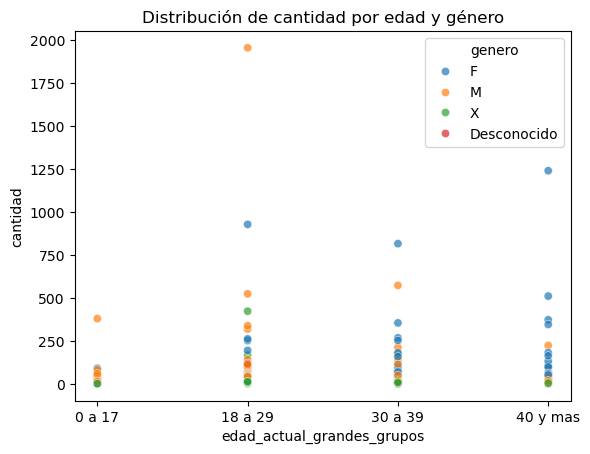

In [150]:
# Scatter plot: cantidad vs grupo de edad
sns.scatterplot(data=df, 
                x='edad_actual_grandes_grupos', 
                y='cantidad', 
                hue='genero', 
                alpha=0.7)

plt.title('Distribución de cantidad por edad y género')
plt.show()

**Se observa**:
* En casi todos los grupos de edad, los puntos de género M tienden a estar más arriba que los de género F y X, mostrando mayor cantidad
* El género X aparece con valores mucho más bajos, pero está presente en casi todas las provincias y grupos de edad, lo cual es un hallazgo interesante
* Los grupos "18 a 29" y "30 a 39" concentran la mayor cantidad de registros altos

### 5. Reflexión final

#### ¿Qué problemas de calidad se identificaron?

* Valores nulos en género
* Registros duplicados
* Inconsistencias en categorías ("40 y +" vs "40 y mas")

#### ¿Cómo impactan en el análisis?

* Los duplicados inflan los totales
* Los nulos y categorías inconsistentes dificultan agrupaciones

#### ¿Qué mejoras adicionales propondría?

* Validar que los grupos de edad sean consistentes en todo el dataset
* Aplicar reglas de negocio para imputar valores faltantes (ej. género)
* Documentar el proceso de limpieza para reproducibilidad